/home/dmytromishkin/big_storage/miniconda/envs/py310/lib/python3.10/site-packages/webdataset/compat.py:379: UserWarning: WebDataset(shardshuffle=...) is None; set explicitly to False or a number
  warnings.warn("WebDataset(shardshuffle=...) is None; set explicitly to False or a number")


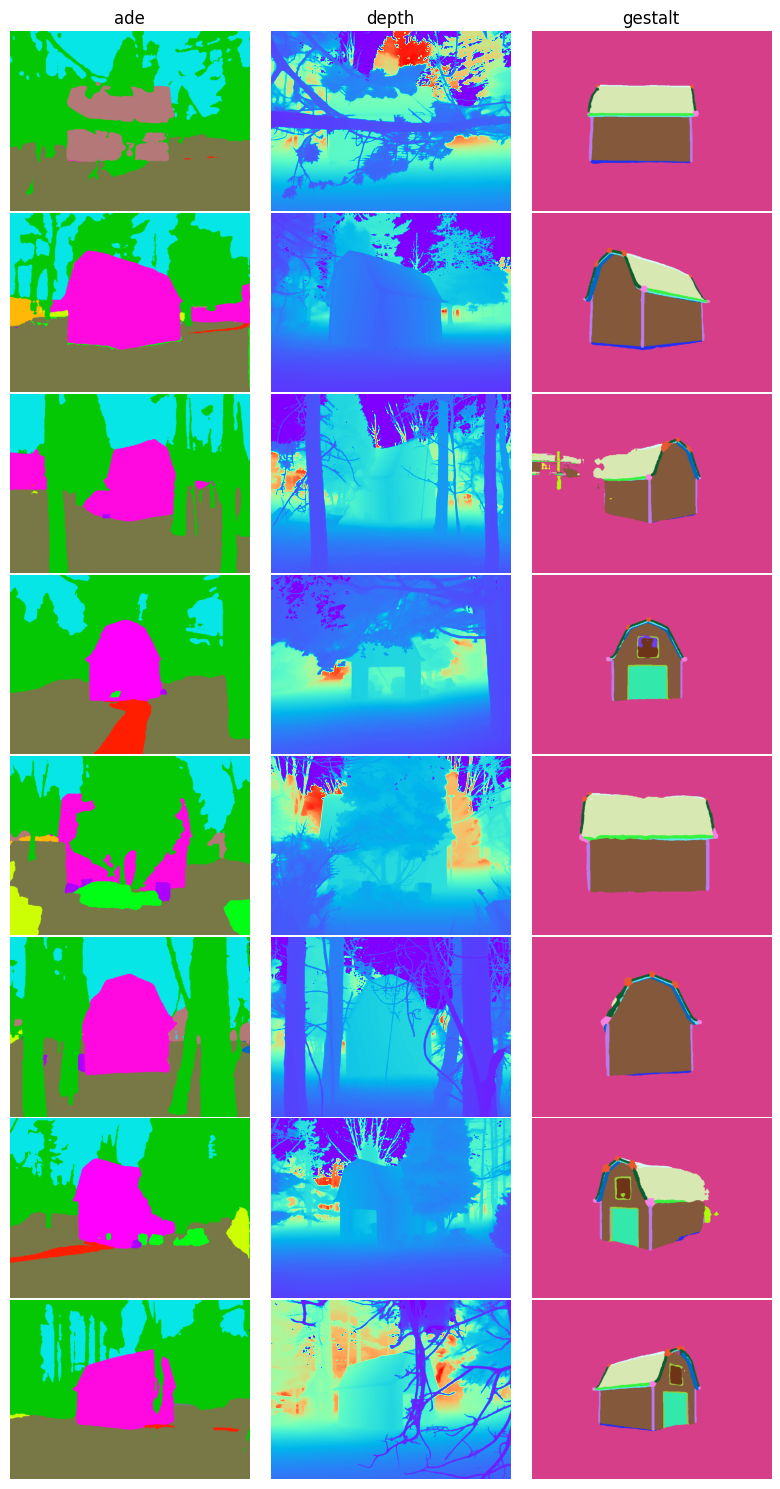

In [1]:
from datasets import load_dataset
from hoho2025.vis import plot_all_modalities
from hoho2025.viz3d import *

def read_colmap_rec(colmap_data):
    import pycolmap
    import tempfile,zipfile
    import io
    with tempfile.TemporaryDirectory() as tmpdir:
        with zipfile.ZipFile(io.BytesIO(colmap_data), "r") as zf:
            zf.extractall(tmpdir)  # unpacks cameras.txt, images.txt, etc. to tmpdir
        # Now parse with pycolmap
        rec = pycolmap.Reconstruction(tmpdir)
        return rec

ds = load_dataset("usm3d/hoho22k_2026_trainval", streaming=True, trust_remote_code=True)
for a in ds['train']:
    break

fig, ax = plot_all_modalities(a)

In [2]:
fig3d = init_figure()
plot_reconstruction(fig3d, read_colmap_rec(a['colmap']))
plot_wireframe(fig3d, a['wf_vertices'], a['wf_edges'], a['wf_classifications'])
plot_bpo_cameras_from_entry(fig3d, a)
fig3d

FigureWidget({
    'data': [{'marker': {'color': array([[167, 153, 114],
                                         [145, 141, 128],
                                         [158, 145, 106],
                                         ...,
                                         [161, 147, 116],
                                         [ 94,  89,  81],
                                         [153, 135, 111]], shape=(40333, 3), dtype=uint8),
                         'line': {'width': 0.0},
                         'size': 1},
              'mode': 'markers',
              'showlegend': False,
              'type': 'scatter3d',
              'uid': 'c8899245-e8a5-4e06-95f7-749a8613e990',
              'x': array([-6.96421957,  3.36013433, -6.98106642, ..., -5.34765188,  3.3834696 ,
                          -5.12186329], shape=(40333,)),
              'y': array([-0.08275994,  1.27877812, -0.07549796, ..., -0.17996222,  4.19697833,
                          -0.21505829], shape=(40333,)),
  

In [3]:
fig3d = init_figure()
plot_depth_and_segmentation_in_3d(fig3d, a, skip_classes=['sky', 'tree'])
plot_wireframe(fig3d, a['wf_vertices'], a['wf_edges'], a['wf_classifications'])
fig3d

FigureWidget({
    'data': [{'marker': {'color': [rgb(180,120,120), rgb(180,120,120),
                                   rgb(180,120,120), ..., rgb(120,120,70),
                                   rgb(120,120,70), rgb(120,120,70)],
                         'line': {'width': 0},
                         'size': 2},
              'mode': 'markers',
              'name': 'depth_89240277672',
              'showlegend': False,
              'type': 'scatter3d',
              'uid': 'f1b54588-18a4-4d11-b018-ba0d92feb0c3',
              'x': array([ 9.12651036,  9.14476195,  9.08891655, ..., 10.84637103, 10.86817691,
                          10.89156695], shape=(5510,)),
              'y': array([2.84706461, 2.84730954, 2.82142318, ..., 0.52170873, 0.52200577,
                          0.52408853], shape=(5510,)),
              'z': array([6.1944886 , 6.16592261, 6.17359351, ..., 4.24709273, 4.22365677,
                          4.20463235], shape=(5510,))},
             {'marker': {'color':

In [4]:
a.keys()


dict_keys(['order_id', 'image_ids', 'ade', 'depth', 'gestalt', 'K', 'R', 't', 'pose_only_in_colmap', 'wf_vertices', 'wf_edges', 'wf_classifications', 'colmap'])

In [2]:
from hoho2025.example_solutions import predict_wireframe
pred_vertices, pred_connections = predict_wireframe(a)

fig3d = init_figure()
plot_reconstruction(fig3d, read_colmap_rec(a['colmap']))
plot_wireframe(fig3d, a['wf_vertices'], a['wf_edges'], a['wf_classifications'])
plot_wireframe(fig3d, pred_vertices, pred_connections, color='rgb(0, 255, 255)')
fig3d

/home/dmytromishkin/big_storage/usm-dataset/hoho2025/hoho2025/example_solutions.py:619: RuntimeWarning: divide by zero encountered in divide
  alpha =np.median(Y/X)


Fitted depth scale k=1.2990 for image 316540519e5
Fitted depth scale k=1.1697 for image 673f130742b
Fitted depth scale k=1.2208 for image 89240277672


/home/dmytromishkin/big_storage/miniconda/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/dmytromishkin/big_storage/miniconda/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Fitted depth scale k=nan for image 9d8b32cd2c4
Fitted depth scale k=1.1162 for image a989fa7858e
Not enough vertices or connections found in image 5, skipping.
Fitted depth scale k=nan for image ca873a17c53
Fitted depth scale k=1.2467 for image cb555e7c886


FigureWidget({
    'data': [{'marker': {'color': array([[167, 153, 114],
                                         [145, 141, 128],
                                         [158, 145, 106],
                                         ...,
                                         [161, 147, 116],
                                         [ 94,  89,  81],
                                         [153, 135, 111]], shape=(40333, 3), dtype=uint8),
                         'line': {'width': 0.0},
                         'size': 1},
              'mode': 'markers',
              'showlegend': False,
              'type': 'scatter3d',
              'uid': '6239665c-1d58-4458-ba79-5b3b06056a4c',
              'x': array([-6.96421957,  3.36013433, -6.98106642, ..., -5.34765188,  3.3834696 ,
                          -5.12186329], shape=(40333,)),
              'y': array([-0.08275994,  1.27877812, -0.07549796, ..., -0.17996222,  4.19697833,
                          -0.21505829], shape=(40333,)),
  

In [3]:
from hoho2025.metric_helper import hss

score = hss(pred_vertices, pred_connections,
            a['wf_vertices'], a['wf_edges'],
            vert_thresh=0.5, edge_thresh=0.5)
print (score)

HSSReturnType(hss=np.float64(0.5513248221240081), f1=np.float64(0.7692307692307692), iou=np.float64(0.42962237145017435))
